# **Convex Optimization Project 5**
Name: Reza Kahidi\
Student Number: 810101249

In [23]:
import cvxpy as cp
import numpy as np
from matplotlib import pyplot as plt

# Data

In [42]:
### Data ###
"""
- T: number of periods (months)
- K: number of CDs
- l: T-array of liabilities
- M: K-array of maturities (months)
- R: K-array of monthly interest rates
- C1: initial cash (in USD)
"""

T = 120
K = 6
l = np.array(
    [
        5.83603919,
        1.49205924,
        2.66109578,
        9.40172515,
        6.47247125,
        0.37633413,
        2.58593829,
        0.85954061,
        0.90192956,
        1.50771989,
        1.15493443,
        4.28137195,
        2.14049632,
        1.12938701,
        1.55871729,
        1.3960884,
        4.45523172,
        0.8145184,
        1.36761412,
        0.42566793,
        0.07784856,
        1.92248495,
        2.37366743,
        0.47608207,
        9.67702601,
        0.23354846,
        1.04682159,
        0.82929126,
        4.63102958,
        4.34644717,
        1.16759657,
        1.45960014,
        0.41156606,
        0.13795931,
        0.70616091,
        1.16923416,
        3.42222417,
        3.32802771,
        0.67886919,
        0.73911426,
        0.35044449,
        0.24170968,
        0.18154165,
        7.0341397,
        0.60070448,
        0.64527784,
        0.28570503,
        2.17600441,
        0.19911,
        0.80836606,
        0.408417,
        1.47241292,
        0.60001229,
        0.30708454,
        0.97221119,
        1.53469532,
        1.06877937,
        1.35319965,
        0.53029486,
        0.6957665,
        0.51045109,
        0.69798814,
        0.44346062,
        0.17794467,
        1.19413986,
        0.66912731,
        0.19589072,
        1.58848742,
        0.40361317,
        1.05331823,
        2.07319431,
        1.13767068,
        3.12489501,
        0.29088542,
        1.49532211,
        0.50418597,
        0.41861772,
        0.56054281,
        0.73230914,
        1.05777256,
        0.31187593,
        2.46163678,
        1.59306915,
        0.2151879,
        4.42934711,
        6.65846632,
        3.25040489,
        0.835333,
        0.34275046,
        2.87040096,
        0.66819385,
        3.39547978,
        1.23155177,
        2.65551613,
        1.42813072,
        2.02703304,
        1.01055534,
        5.96476998,
        1.13531721,
        1.49479543,
        6.57418553,
        0.25982185,
        0.28069545,
        2.63635349,
        0.30939905,
        6.98399558,
        0.66125285,
        0.47357035,
        6.84105546,
        4.39520771,
        6.47247753,
        2.4745156,
        0.42264374,
        6.75352745,
        0.7649052,
        2.23101446,
        2.5786138,
        0.85640653,
        1.84795453,
        2.51483368,
    ]
)
M = np.array([1, 3, 6, 12, 24, 36])
R = np.array([1, 2, 3, 4, 5, 6]) / 100 / 12
C1 = l.sum()


# Problem

In [68]:
C = cp.Variable((T+1, 1))
Z = cp.Variable((T, K), nonneg=True)

obj = cp.Maximize(C[-1])

const = [C[0] == C1]
for t in range(T):
    F = cp.sum(Z[t, :])
    G = 0
    for k in range(K):
        if t - M[k] >= 0:
            G += Z[t - M[k], k] * (1 + R[k]) ** M[k]
    if t < T:
        const += [C[t + 1] == C[t] - l[t] - F + G]
    const += [C[t] >= 0]

prob = cp.Problem(obj, const)
prob.solve()

Z_star = Z.value
print("Problem Status:", prob.status)
print("Optimal Value =", prob.value)

Problem Status: optimal
Optimal Value = 91.3295230533519


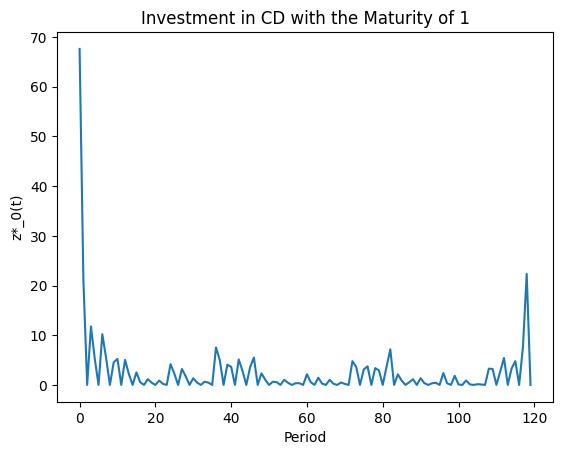

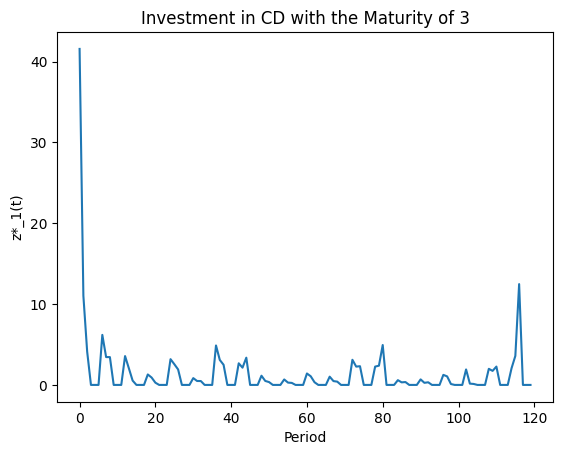

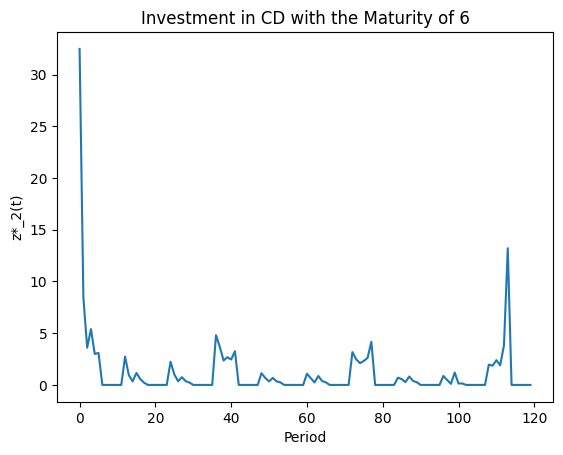

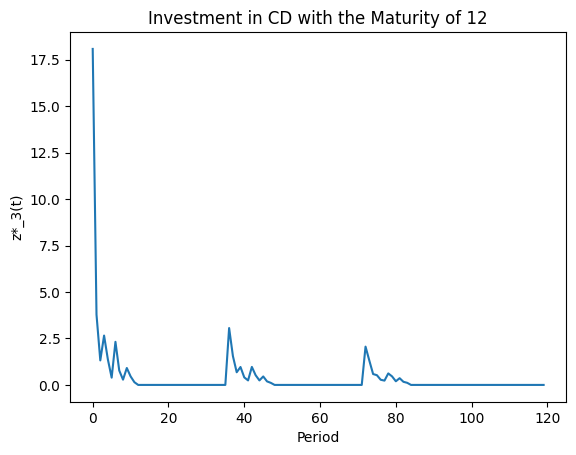

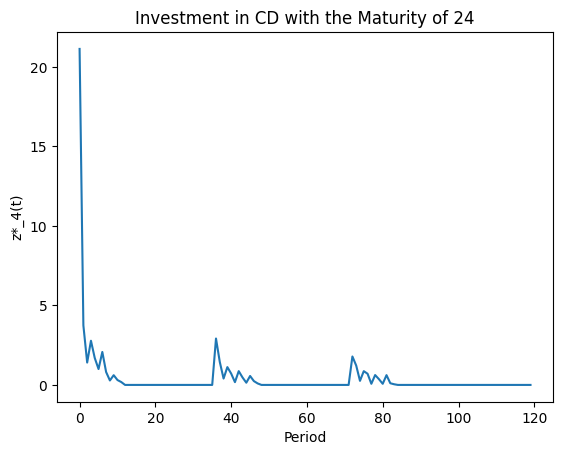

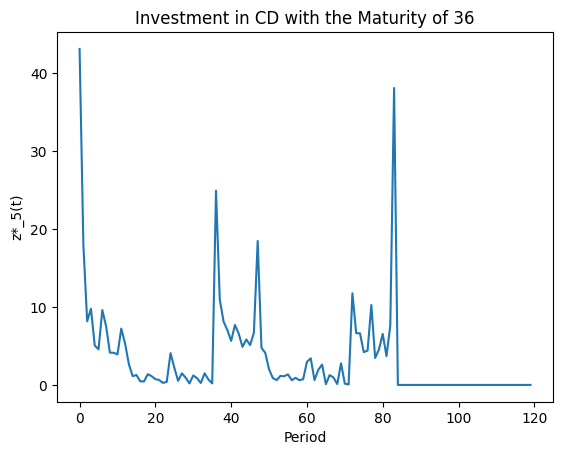

In [88]:
for k in range(K):
    plt.figure()
    plt.plot(range(T), Z_star[:, k])
    plt.title(f"Investment in CD with the Maturity of {M[k]}")
    plt.xlabel("Period")
    plt.ylabel(f'z*_{k}(t)')
    plt.show()

In [103]:
# Baseline policy: invest all available cash each period in CDs with M = 1 month
C_baseline = np.zeros(T + 1)
C_baseline[0] = C1

for t in range(T):
    if t > 0:
        C_baseline[t] += C_baseline[t - 1] * R[0]
    C_baseline[t] -= l[t]
    C_baseline[t + 1] = C_baseline[t] # Reinvest all available cash in CD with M = 1 month

print("Baseline final cash value = " ,C_baseline[-1])

Baseline final cash value =  12.328510876340276
